# Autonomous NBV Inspection Policy: Comprehensive Parameter Matrix Benchmark Analysis

This notebook provides a comprehensive diagnostic, visual, and statistical evaluation of the Next-Best-View (NBV) inspection agent across the full operational parameter matrix (`benchmark_raw_data_matrix.csv`).

The evaluation matrix spans 8 distinct operational configurations across:
1. **Maneuver Fuel Budget ($\Delta v$):** Tight (100 m/s), Moderate (200 m/s), Extended (300 m/s), and Unconstrained (500 m/s)
2. **Orbital Inspection Duration:** Short (2 orbits), Nominal (3 orbits), and Extended (5 orbits)
3. **Action Step Horizon:** Rapid (10 steps), Standard (30 steps), and Extended (50 steps)
4. **Safety Keep-Out Zone (KOZ) Standoff:** Tight ($r_{\text{koz}} = 0.85$), Nominal ($r_{\text{koz}} = 0.95$), and Wide ($r_{\text{koz}} = 1.05$)

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Configure premium publication plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

POLICY_COLORS = {
    "PPO": "#1f77b4",     # Blue
    "Spiral": "#ff7f0e",  # Orange
    "Random": "#2ca02c",  # Green
}

# Output figure directory for publication
FIG_DIR = "docs/paper/figures"
os.makedirs(FIG_DIR, exist_ok=True)

---

## 1. Load and Preprocess Matrix Benchmark Data

We load the raw CSV, standardize all derived metrics (coverage percentage, fuel consumed percentage, mission time fraction, orbital radius), and index the 8 parameter matrix configurations.

In [2]:
matrix_csv_path = "artefacts/benchmark/benchmark_raw_data_matrix.csv"
fallback_csv_path = "artefacts/benchmark/benchmark_raw_data.csv"

if os.path.exists(matrix_csv_path):
    df = pd.read_csv(matrix_csv_path)
    print(f"Loaded matrix data from '{matrix_csv_path}': {len(df):,} records.")
elif os.path.exists(fallback_csv_path):
    df = pd.read_csv(fallback_csv_path)
    print(f"Matrix CSV not found. Loaded fallback data from '{fallback_csv_path}': {len(df):,} records.")
else:
    raise FileNotFoundError("No benchmark data CSV found in 'artefacts/benchmark/'. Please run benchmark.py first.")

# Standardize configuration columns if missing in legacy datasets
if "config_fuel_budget" not in df.columns:
    df["config_fuel_budget"] = 100.0
if "config_num_orbits" not in df.columns:
    df["config_num_orbits"] = 2.0
if "config_max_step" not in df.columns:
    df["config_max_step"] = 30
if "config_koz_radius" not in df.columns:
    df["config_koz_radius"] = 0.95

# Derived metrics
df["coverage_pct"] = df["coverage"] * 100.0
df["coverage_gain_pct"] = df["coverage_gain"] * 100.0
df["fuel_pct_consumed"] = df["fuel_consumed_fraction"] * 100.0

# Camera distance from origin (chief center)
if "viewpoint_distance" not in df.columns or df["viewpoint_distance"].isna().all():
    df["viewpoint_distance"] = np.sqrt(df["camera_x"]**2 + df["camera_y"]**2 + df["camera_z"]**2)

# Configuration labeling map (covers all 8 operational parameter matrix configurations)
CONFIG_LABELS = {
    (100.0, 2.0, 10, 0.95): "InDist-10 (100 m/s, 2 orbits, 10 steps)",
    (100.0, 2.0, 30, 0.95): "InDist-30 (100 m/s, 2 orbits, 30 steps)",
    (200.0, 2.0, 30, 0.95): "Budget-200 (200 m/s, 2 orbits, 30 steps)",
    (300.0, 3.0, 30, 0.95): "Budget-300 (300 m/s, 3 orbits, 30 steps)",
    (500.0, 5.0, 30, 0.95): "OOD-500-30 (500 m/s, 5 orbits, 30 steps)",
    (500.0, 5.0, 50, 0.95): "OOD-500-50 (500 m/s, 5 orbits, 50 steps)",
    (500.0, 5.0, 30, 0.85): "KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)",
    (500.0, 5.0, 30, 1.05): "KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)",
}

df["config_label"] = df.apply(
    lambda r: CONFIG_LABELS.get(
        (float(r["config_fuel_budget"]), float(r["config_num_orbits"]), int(r["config_max_step"]), round(float(r["config_koz_radius"]), 2)),
        f"Fuel {r['config_fuel_budget']}m, Orb {r['config_num_orbits']}, Step {r['config_max_step']}, KOZ {r['config_koz_radius']}"
    ),
    axis=1
)

# Extract terminal step for every unique episode
ep_group_cols = ["dataset_split", "policy", "model_name", "loop_id", "config_label"]
idx_final = df.groupby(ep_group_cols)["step"].idxmax()
df_final = df.loc[idx_final].copy()

# Robust collision flag across the episode trajectory
had_collision = df.groupby(ep_group_cols)["collision_detected"].any()
df_final["had_collision"] = df_final.set_index(ep_group_cols).index.map(had_collision)

print(f"Total Unique Evaluation Episodes: {len(df_final):,}")
print("Config breakdown:")
display(df_final["config_label"].value_counts().to_frame("Episode Count"))

Loaded matrix data from 'artefacts/benchmark/benchmark_raw_data_matrix.csv': 27,051 records.
Total Unique Evaluation Episodes: 1,536
Config breakdown:


,Episode Count
config_label,
"Budget-200 (200 m/s, 2 orbits, 30 steps)",192
"Budget-300 (300 m/s, 3 orbits, 30 steps)",192
"InDist-10 (100 m/s, 2 orbits, 10 steps)",192
"InDist-30 (100 m/s, 2 orbits, 30 steps)",192
"KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)",192
"KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)",192
"OOD-500-30 (500 m/s, 5 orbits, 30 steps)",192
"OOD-500-50 (500 m/s, 5 orbits, 50 steps)",192


,Episode Count
config_label,
"Budget-200 (200 m/s, 2 orbits, 30 steps)",192
"Budget-300 (300 m/s, 3 orbits, 30 steps)",192
"InDist-10 (100 m/s, 2 orbits, 10 steps)",192
"InDist-30 (100 m/s, 2 orbits, 30 steps)",192
"KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)",192
"KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)",192
"OOD-500-30 (500 m/s, 5 orbits, 30 steps)",192
"OOD-500-50 (500 m/s, 5 orbits, 50 steps)",192


---

## 2. Global Performance & Metric Tables

We compute clean, publication-ready performance tables (Mean $\pm$ Standard Deviation) for each split, configuration, and policy.

In [3]:
# 1. In-Distribution Performance Table (30 steps vs 10 steps)
for indist_name in ["InDist-30 (100 m/s, 2 orbits, 30 steps)", "InDist-10 (100 m/s, 2 orbits, 10 steps)"]:
    indist_sub = df_final[df_final["config_label"] == indist_name]
    summary = indist_sub.groupby(["policy", "dataset_split"])["coverage_pct"].agg(["mean", "std", "count"]).round(2)
    summary["Formatted"] = summary.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}% (N={int(r['count'])})", axis=1)
    print(f"\n=== {indist_name} Coverage Summary ===")
    display(summary["Formatted"].unstack("dataset_split")[["Train", "Val", "Test"]])

# 2. Complete Parameter Matrix Summary (Test Split)
test_final = df_final[df_final["dataset_split"] == "Test"]
test_matrix_summary = test_final.groupby(["config_label", "policy"]).agg({
    "coverage_pct": ["mean", "std"],
    "fuel_pct_consumed": "mean",
    "cumulative_dv": "mean",
    "step": "mean",
    "had_collision": ["sum", "mean"]
}).round(2)

test_matrix_summary.columns = [
    "Coverage Mean (%)", "Coverage Std (%)",
    "Fuel Consumed (%)", "Delta-v (m/s)", "Final Steps",
    "Collisions", "Collision Rate"
]
test_matrix_summary["Collision Rate"] = (test_matrix_summary["Collision Rate"] * 100.0).round(2).astype(str) + "%"

print("\n=== Test Split Performance Across All 8 Matrix Configurations ===")
display(test_matrix_summary)

# 3. Overall Safety & Collision Incident Summary
print("\n=== Safety Performance: Collision Incident Summary Across All 1,536 Episodes ===")
collision_summary = df_final.groupby("policy")["had_collision"].agg(["count", "sum"])
collision_summary["Collision-Free Rate (%)"] = ((1.0 - collision_summary["sum"] / collision_summary["count"]) * 100.0).round(2)
collision_summary.columns = ["Total Episodes", "Collision Incidents", "Collision-Free Rate (%)"]
display(collision_summary)


=== InDist-30 (100 m/s, 2 orbits, 30 steps) Coverage Summary ===


dataset_split,Train,Val,Test
policy,,,
PPO,73.48 ± 13.28% (N=44),74.31 ± 16.40% (N=9),77.14 ± 7.76% (N=11)
Random,33.90 ± 12.98% (N=44),44.27 ± 12.05% (N=9),38.99 ± 10.90% (N=11)
Spiral,37.80 ± 10.20% (N=44),40.42 ± 14.11% (N=9),34.91 ± 5.91% (N=11)



=== InDist-10 (100 m/s, 2 orbits, 10 steps) Coverage Summary ===


dataset_split,Train,Val,Test
policy,,,
PPO,73.71 ± 13.72% (N=44),74.41 ± 17.87% (N=9),75.23 ± 6.53% (N=11)
Random,35.17 ± 13.20% (N=44),37.56 ± 17.10% (N=9),39.84 ± 13.20% (N=11)
Spiral,54.31 ± 8.26% (N=44),58.65 ± 14.43% (N=9),56.23 ± 7.26% (N=11)



=== Test Split Performance Across All 8 Matrix Configurations ===


Coverage Mean (%)  \
config_label                             policy                      
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                 79.98   
                                         Random              40.85   
                                         Spiral              65.05   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                 86.10   
                                         Random              40.36   
                                         Spiral              72.38   
InDist-10 (100 m/s, 2 orbits, 10 steps)  PPO                 75.23   
                                         Random              39.84   
                                         Spiral              56.23   
InDist-30 (100 m/s, 2 orbits, 30 steps)  PPO                 77.14   
                                         Random              38.99   
                                         Spiral              34.91   
KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)  PPO                 84.74   
                                         Random              40.59   
                                         Spiral              72.69   
KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)   PPO                 83.95   
                                         Random              37.54   
                                         Spiral              72.69   
OOD-500-30 (500 m/s, 5 orbits, 30 steps) PPO                 83.35   
                                         Random              44.78   
                                         Spiral              72.69   
OOD-500-50 (500 m/s, 5 orbits, 50 steps) PPO                 85.76   
                                         Random              39.06   
                                         Spiral              74.52   

                                                 Coverage Std (%)  \
config_label                             policy                     
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                 8.44   
                                         Random             15.18   
                                         Spiral              5.22   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                 6.60   
                                         Random             10.54   
                                         Spiral              5.31   
InDist-10 (100 m/s, 2 orbits, 10 steps)  PPO                 6.53   
                                         Random             13.20   
                                         Spiral              7.26   
InDist-30 (100 m/s, 2 orbits, 30 steps)  PPO                 7.76   
                                         Random             10.90   
                                         Spiral              5.91   
KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)  PPO                 6.61   
                                         Random             13.87   
                                         Spiral              4.85   
KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)   PPO                 7.55   
                                         Random              9.87   
                                         Spiral              4.85   
OOD-500-30 (500 m/s, 5 orbits, 30 steps) PPO                 7.32   
                                         Random             12.28   
                                         Spiral              4.85   
OOD-500-50 (500 m/s, 5 orbits, 50 steps) PPO                 7.99   
                                         Random             15.09   
                                         Spiral              4.64   

                                                 Fuel Consumed (%)  \
config_label                             policy                      
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                 96.69   
                                         Random              25.43   
                                         Spiral             100.40   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                 89.35   
             


=== Safety Performance: Collision Incident Summary Across All 1,536 Episodes ===


,Total Episodes,Collision Incidents,Collision-Free Rate (%)
policy,,,
PPO,512,0,100.00
Random,512,3,99.41
Spiral,512,3,99.41


---

## 3. Step-by-Step Trajectory Dynamics (Min-Max Bands & Spread)

These plots display the step-by-step surface coverage accumulation, cumulative fuel consumption, and marginal coverage gain per step with shaded min-max spread across all evaluated spacecraft models.

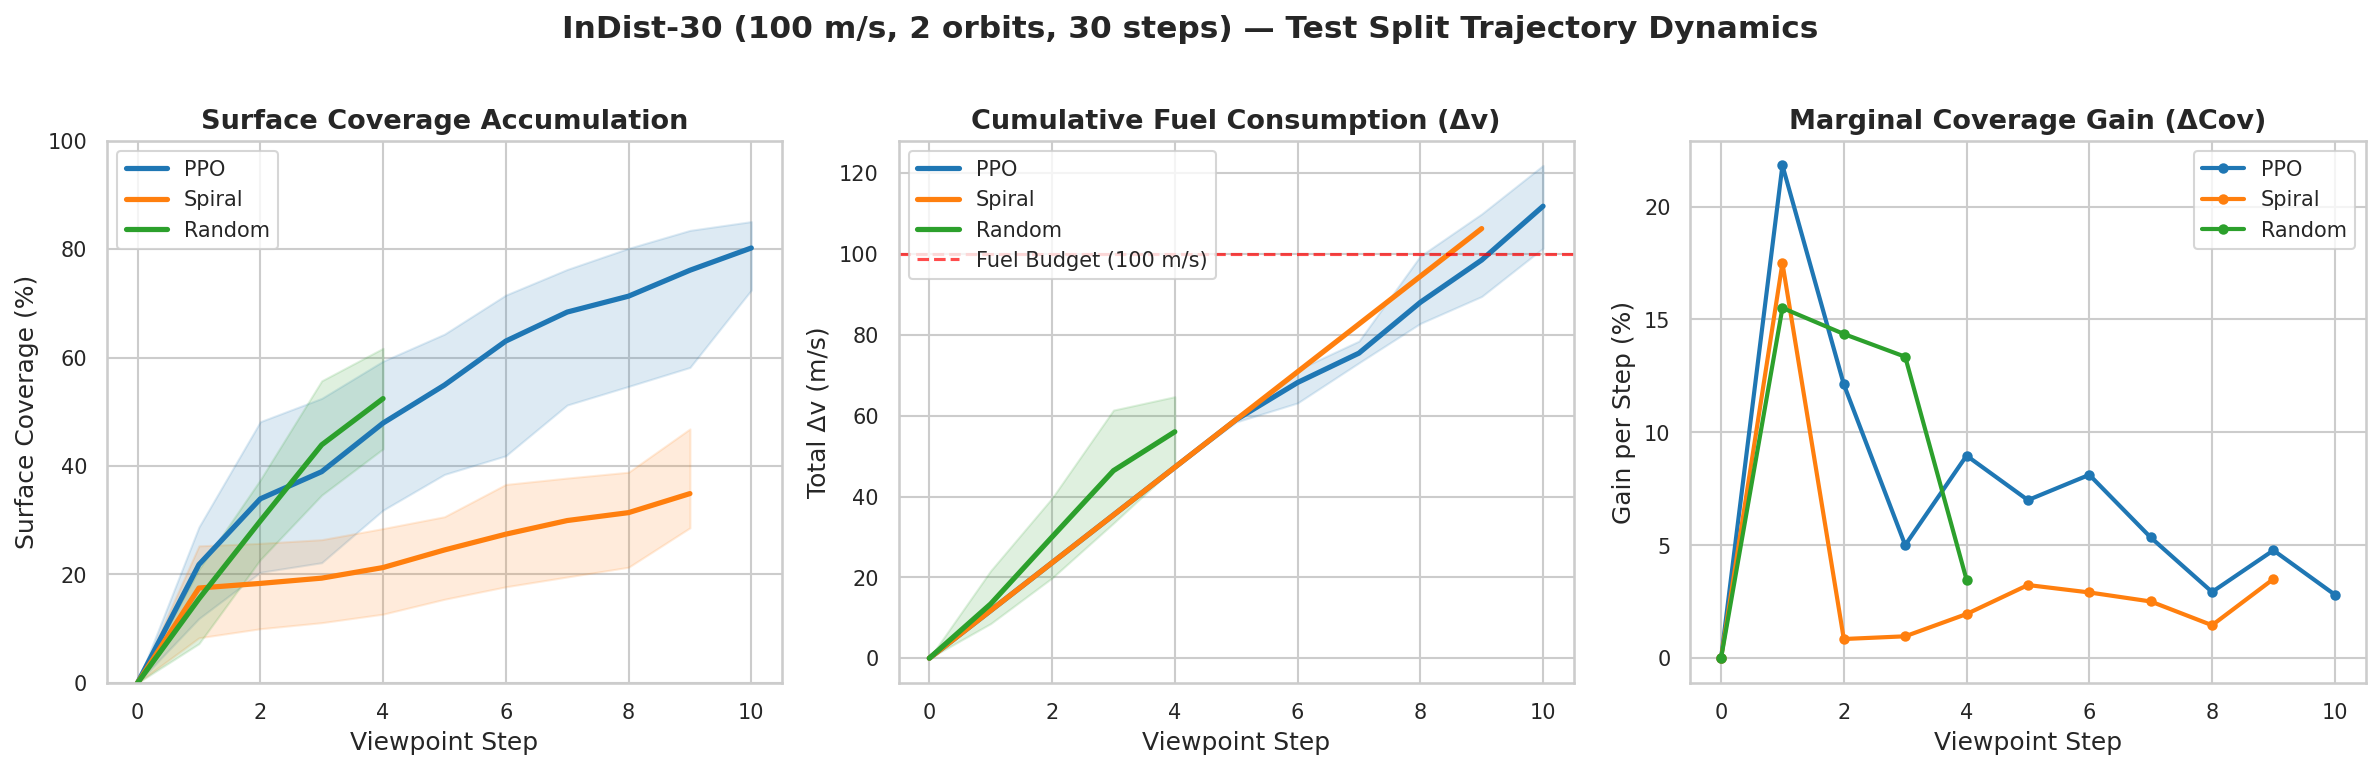

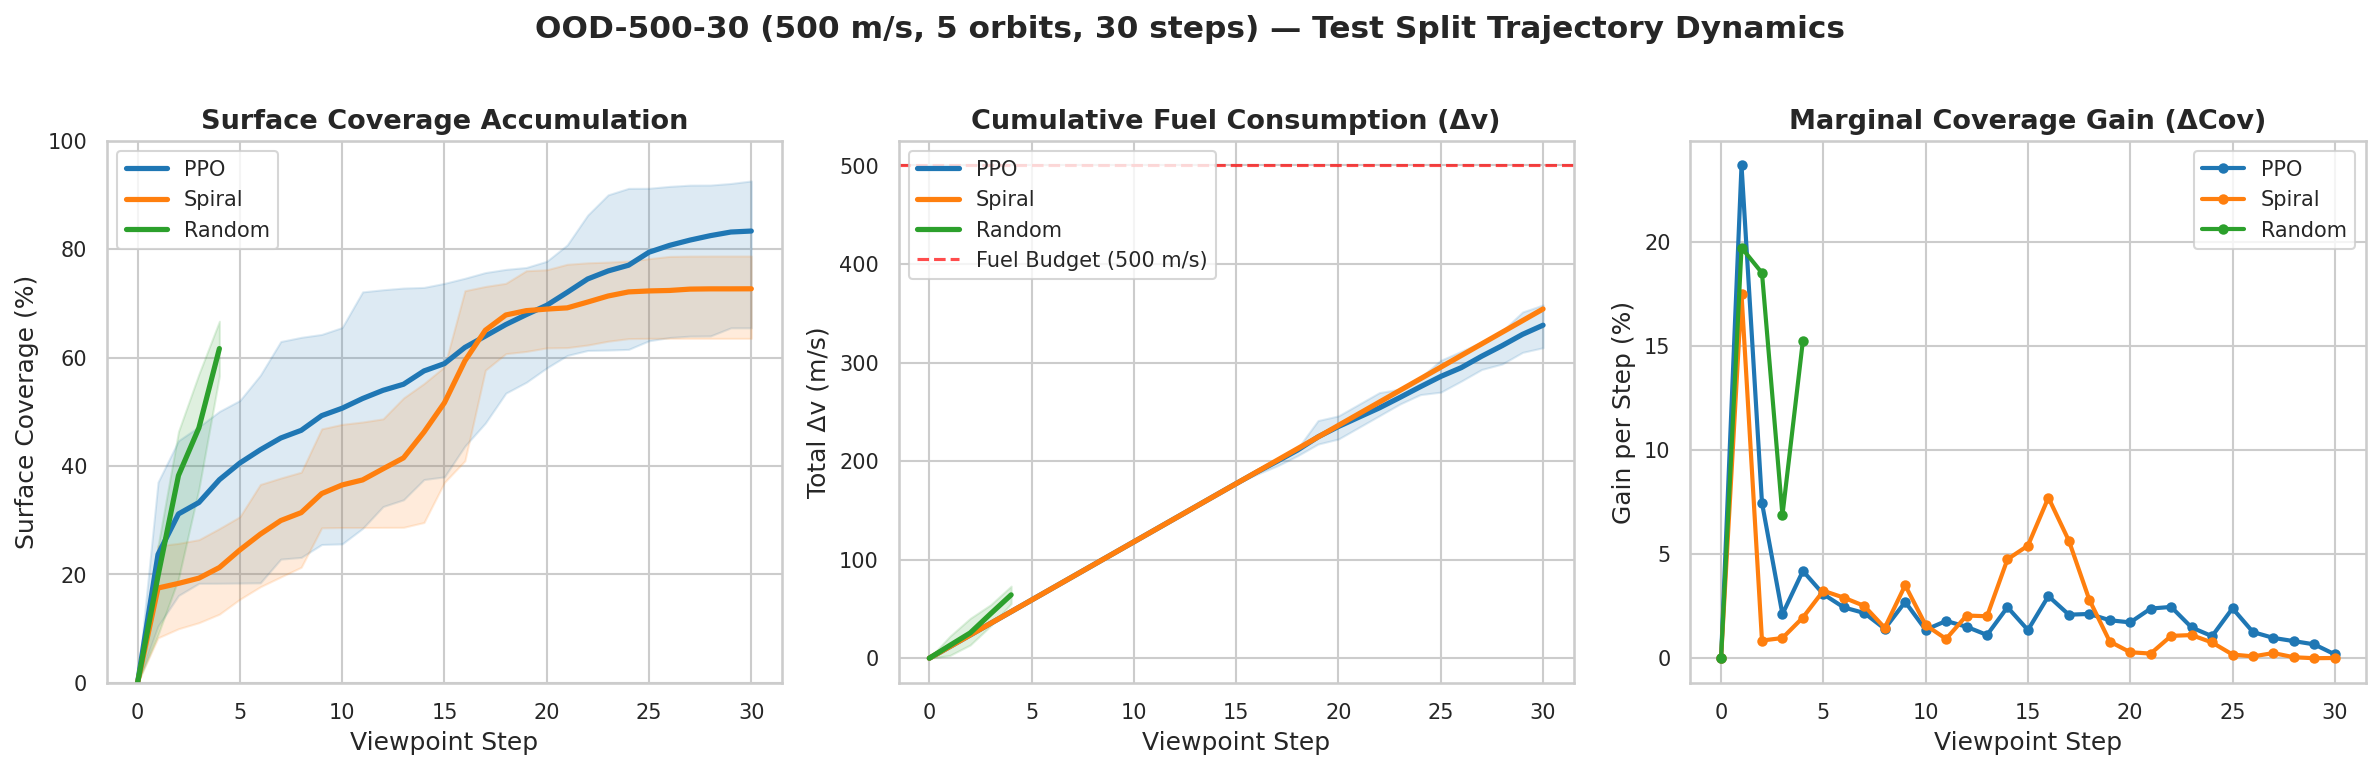

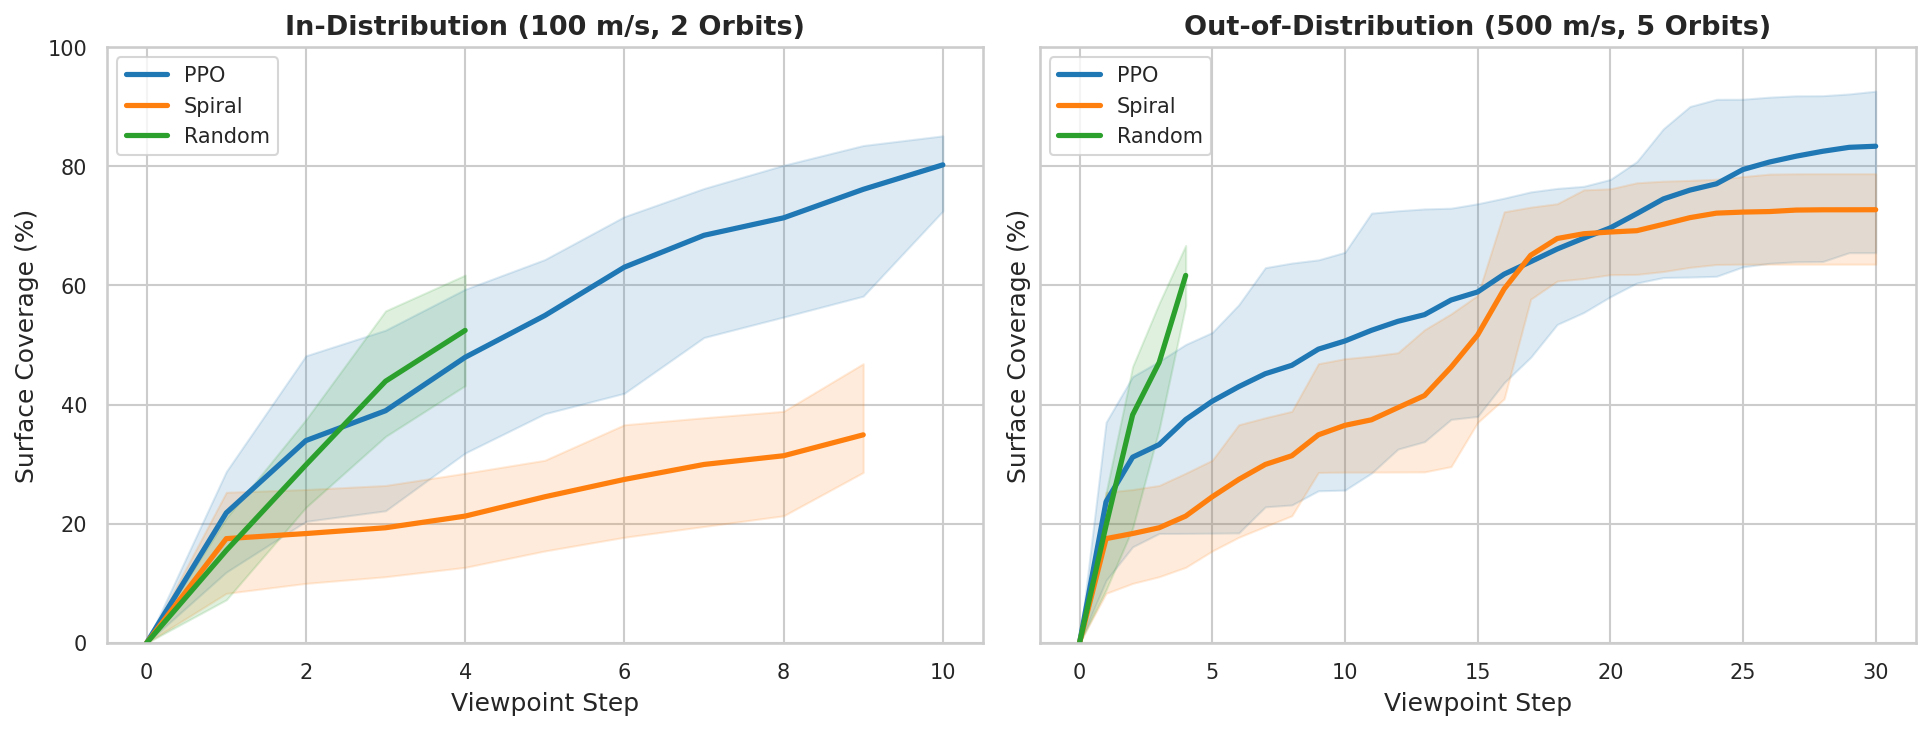

Exported publication figure to docs/paper/figures/fig_coverage_curves.pdf


In [4]:
def plot_step_metric_dynamics(df_data, config_name, split_name="Test", figsize=(16, 5)):
    subset = df_data[(df_data["config_label"] == config_name) & (df_data["dataset_split"] == split_name)]
    if subset.empty:
        print(f"No data for {config_name} on {split_name} split.")
        return
        
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    policies = [p for p in ["PPO", "Spiral", "Random"] if p in subset["policy"].unique()]
    
    # Panel 1: Surface Coverage Accumulation
    ax1 = axes[0]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["coverage_pct"].agg(["mean", "min", "max"]).reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax1.plot(stats["step"], stats["mean"], label=pol, color=color, linewidth=2.5)
        ax1.fill_between(stats["step"], stats["min"], stats["max"], color=color, alpha=0.15)
        
    ax1.set_title("Surface Coverage Accumulation", fontweight="bold")
    ax1.set_xlabel("Viewpoint Step")
    ax1.set_ylabel("Surface Coverage (%)")
    ax1.set_ylim(0, 100)
    ax1.legend(loc="upper left")
    
    # Panel 2: Cumulative Fuel Consumption (Delta-v)
    ax2 = axes[1]
    fuel_budget = subset["config_fuel_budget"].iloc[0]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["cumulative_dv"].agg(["mean", "min", "max"]).reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax2.plot(stats["step"], stats["mean"], label=pol, color=color, linewidth=2.5)
        ax2.fill_between(stats["step"], stats["min"], stats["max"], color=color, alpha=0.15)
        
    ax2.axhline(fuel_budget, color="red", linestyle="--", alpha=0.7, label=f"Fuel Budget ({fuel_budget:.0f} m/s)")
    ax2.set_title("Cumulative Fuel Consumption (Δv)", fontweight="bold")
    ax2.set_xlabel("Viewpoint Step")
    ax2.set_ylabel("Total Δv (m/s)")
    ax2.legend(loc="upper left")
    
    # Panel 3: Marginal Coverage Gain per Step
    ax3 = axes[2]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["coverage_gain_pct"].mean().reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax3.plot(stats["step"], stats["coverage_gain_pct"], label=pol, color=color, linewidth=2.0, marker="o", markersize=4)
        
    ax3.set_title("Marginal Coverage Gain (ΔCov)", fontweight="bold")
    ax3.set_xlabel("Viewpoint Step")
    ax3.set_ylabel("Gain per Step (%)")
    ax3.legend(loc="upper right")
    
    plt.suptitle(f"{config_name} — {split_name} Split Trajectory Dynamics", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# 1. In-Distribution Dynamics (Test Set)
plot_step_metric_dynamics(df, "InDist-30 (100 m/s, 2 orbits, 30 steps)", "Test")

# 2. Out-of-Distribution Dynamics (Test Set)
plot_step_metric_dynamics(df, "OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "Test")

# 3. Export Paper Publication Figure: fig_coverage_curves
fig_pub, axes_pub = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
scenarios = [
    ("InDist-30 (100 m/s, 2 orbits, 30 steps)", "In-Distribution (100 m/s, 2 Orbits)", axes_pub[0]),
    ("OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "Out-of-Distribution (500 m/s, 5 Orbits)", axes_pub[1]),
]

for cfg_name, title, ax in scenarios:
    sub = df[(df["config_label"] == cfg_name) & (df["dataset_split"] == "Test")]
    for pol in ["PPO", "Spiral", "Random"]:
        pol_sub = sub[sub["policy"] == pol]
        stats = pol_sub.groupby("step")["coverage_pct"].agg(["mean", "min", "max"]).reset_index()
        color = POLICY_COLORS[pol]
        ax.plot(stats["step"], stats["mean"], label=pol, color=color, linewidth=2.5)
        ax.fill_between(stats["step"], stats["min"], stats["max"], color=color, alpha=0.15)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Viewpoint Step")
    ax.set_ylabel("Surface Coverage (%)")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left")

plt.tight_layout()
fig_pub.savefig(os.path.join(FIG_DIR, "fig_coverage_curves.pdf"), bbox_inches="tight")
fig_pub.savefig(os.path.join(FIG_DIR, "fig_coverage_curves.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Exported publication figure to {FIG_DIR}/fig_coverage_curves.pdf")

---

## 4. Operational Budget Scaling Sweep

We analyze how agent performance and heuristic baselines scale across the budget continuum: 100 m/s (2 orbits) $\to$ 200 m/s (2 orbits) $\to$ 300 m/s (3 orbits) $\to$ 500 m/s (5 orbits).

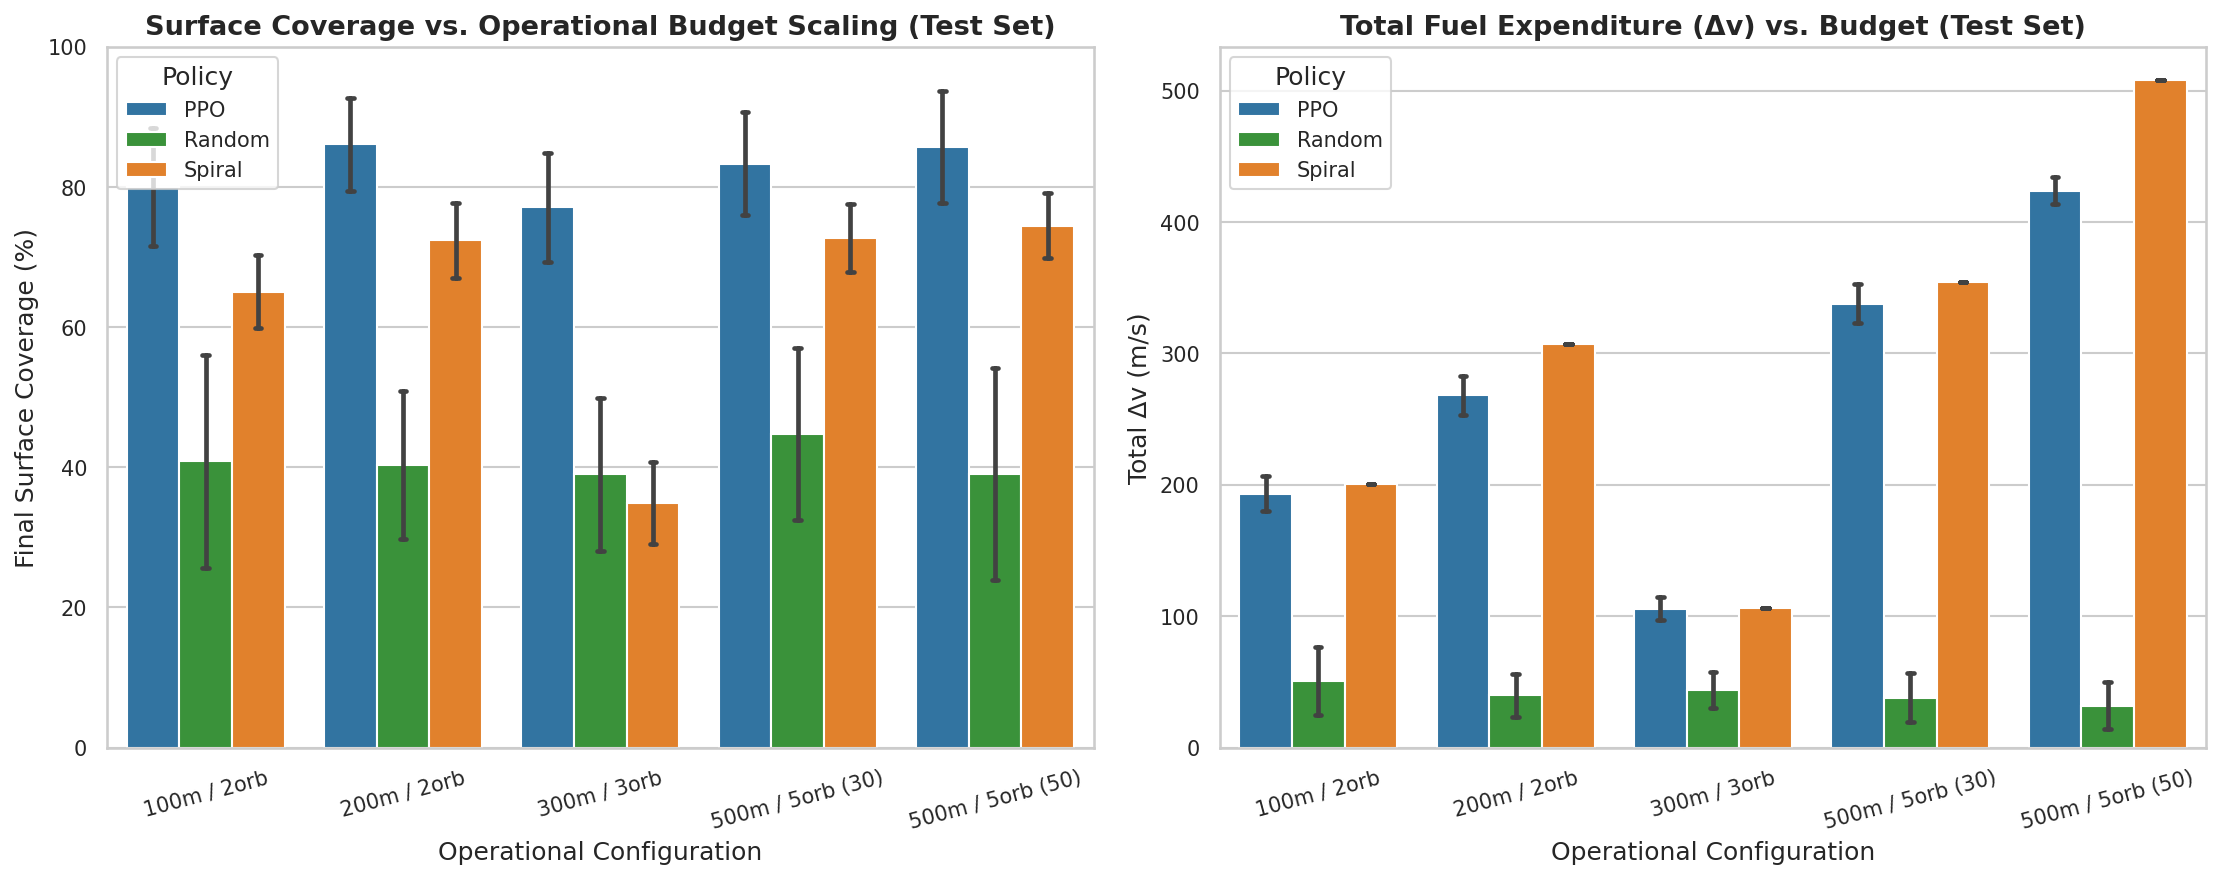

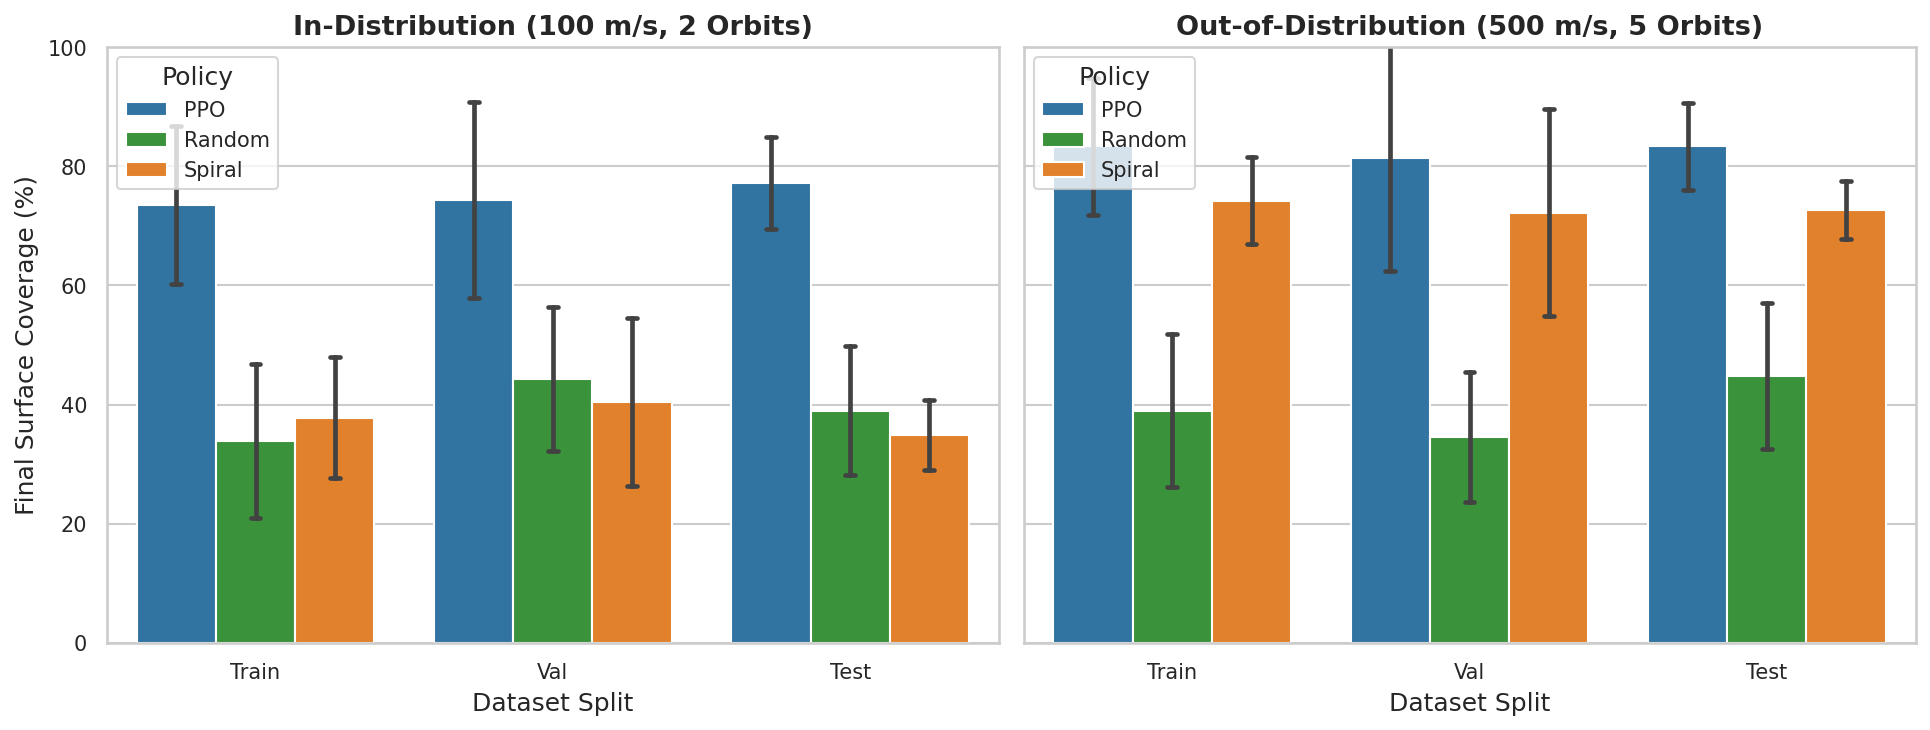

Exported publication figures to docs/paper/figures


In [5]:
sweep_configs = [
    "InDist-30 (100 m/s, 2 orbits, 30 steps)",
    "Budget-200 (200 m/s, 2 orbits, 30 steps)",
    "Budget-300 (300 m/s, 3 orbits, 30 steps)",
    "OOD-500-30 (500 m/s, 5 orbits, 30 steps)",
    "OOD-500-50 (500 m/s, 5 orbits, 50 steps)",
]

sweep_data = df_final[(df_final["config_label"].isin(sweep_configs)) & (df_final["dataset_split"] == "Test")]
sweep_labels = ["100m / 2orb", "200m / 2orb", "300m / 3orb", "500m / 5orb (30)", "500m / 5orb (50)"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Final Coverage vs. Budget Configuration
ax1 = axes[0]
sns.barplot(
    data=sweep_data, 
    x="config_label", 
    y="coverage_pct", 
    hue="policy", 
    palette=POLICY_COLORS, 
    ax=ax1, 
    errorbar="sd", 
    capsize=0.1
)
ax1.set_title("Surface Coverage vs. Operational Budget Scaling (Test Set)", fontweight="bold")
ax1.set_xlabel("Operational Configuration")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_xticks(range(len(sweep_labels)))
ax1.set_xticklabels(sweep_labels, rotation=15)
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="upper left")

# Panel 2: Total Delta-v Consumed vs. Fuel Budget
ax2 = axes[1]
sns.barplot(
    data=sweep_data, 
    x="config_label", 
    y="cumulative_dv", 
    hue="policy", 
    palette=POLICY_COLORS, 
    ax=ax2, 
    errorbar="sd", 
    capsize=0.1
)
ax2.set_title("Total Fuel Expenditure (Δv) vs. Budget (Test Set)", fontweight="bold")
ax2.set_xlabel("Operational Configuration")
ax2.set_ylabel("Total Δv (m/s)")
ax2.set_xticks(range(len(sweep_labels)))
ax2.set_xticklabels(sweep_labels, rotation=15)
ax2.legend(title="Policy", loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_matrix_sweep.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig_matrix_sweep.png"), dpi=300, bbox_inches="tight")
plt.show()

# Export Paper Figure: fig_final_coverage_bar across In-Dist and OOD
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
bar_configs = [
    ("InDist-30 (100 m/s, 2 orbits, 30 steps)", "In-Distribution (100 m/s, 2 Orbits)", axes_bar[0]),
    ("OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "Out-of-Distribution (500 m/s, 5 Orbits)", axes_bar[1]),
]

for cfg_name, title, ax in bar_configs:
    sub = df_final[df_final["config_label"] == cfg_name]
    sns.barplot(
        data=sub,
        x="dataset_split",
        y="coverage_pct",
        hue="policy",
        order=["Train", "Val", "Test"],
        palette=POLICY_COLORS,
        ax=ax,
        errorbar="sd",
        capsize=0.1
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel("Final Surface Coverage (%)")
    ax.set_ylim(0, 100)
    ax.legend(title="Policy", loc="upper left")

plt.tight_layout()
fig_bar.savefig(os.path.join(FIG_DIR, "fig_final_coverage_bar.pdf"), bbox_inches="tight")
fig_bar.savefig(os.path.join(FIG_DIR, "fig_final_coverage_bar.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Exported publication figures to {FIG_DIR}")

---

## 5. Safety Standoff (KOZ Radius) Sensitivity

We evaluate how Keep-Out Zone standoff radius variations ($r_{\text{koz}} \in \{0.85, 0.95, 1.05\}$) affect path planning, safety, and final coverage.

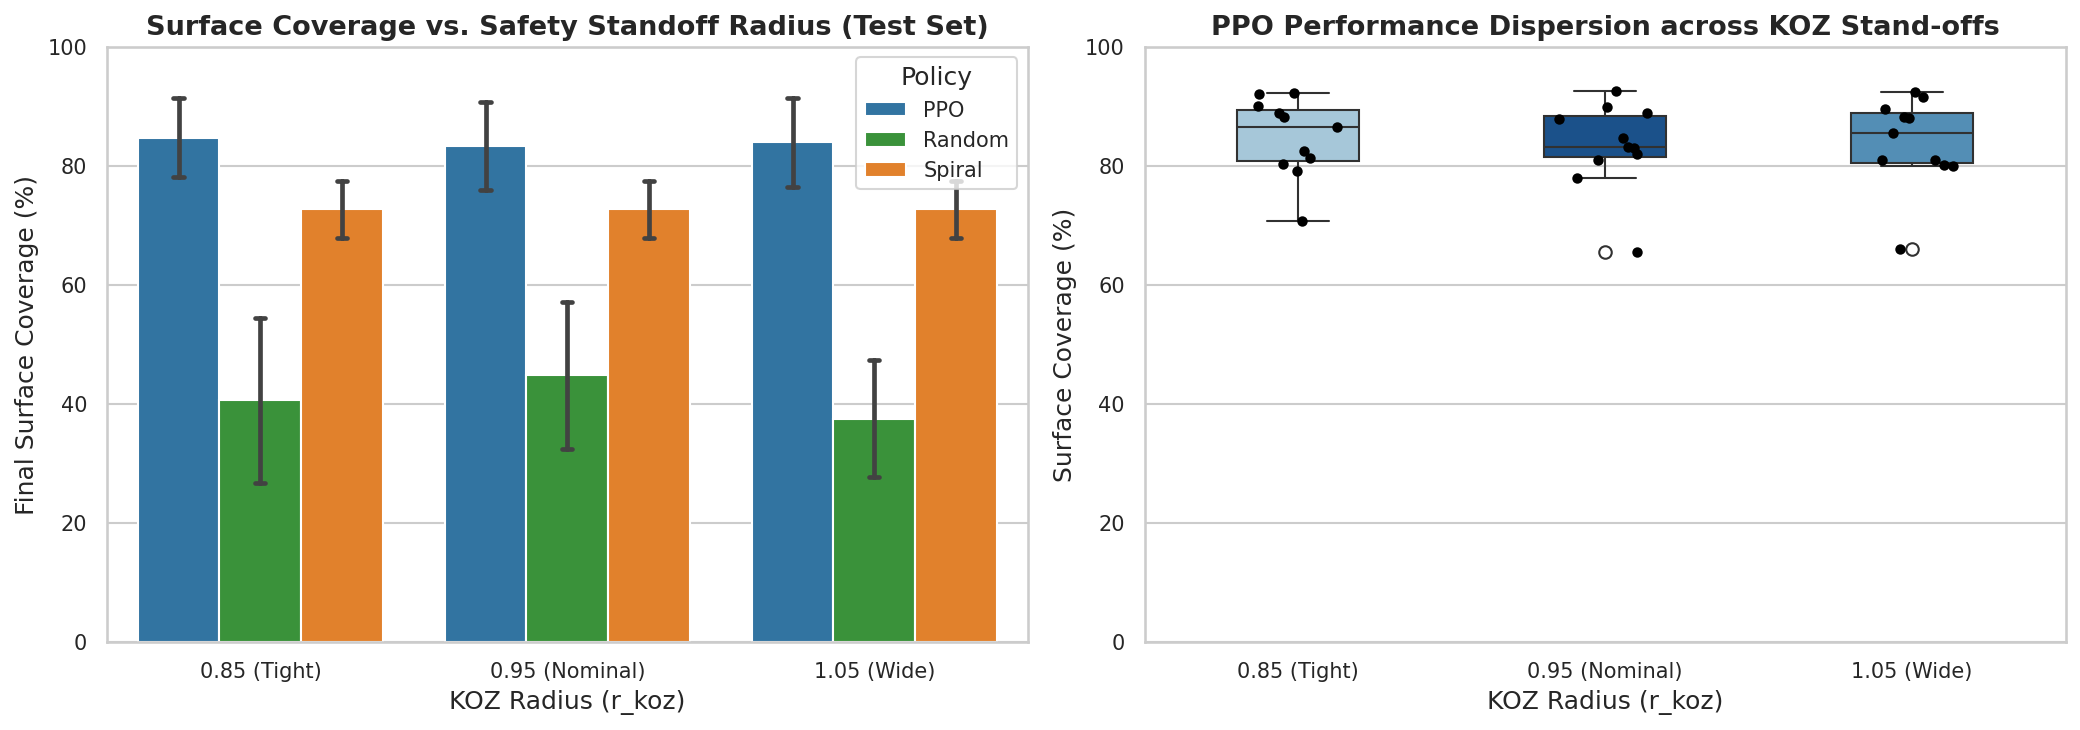

Exported docs/paper/figures/fig_koz_sensitivity.pdf


In [6]:
koz_configs = [
    "KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)",
    "OOD-500-30 (500 m/s, 5 orbits, 30 steps)",
    "KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)",
]

koz_data = df_final[(df_final["config_label"].isin(koz_configs)) & (df_final["dataset_split"] == "Test")].copy()
koz_map = {
    0.85: "0.85 (Tight)",
    0.95: "0.95 (Nominal)",
    1.05: "1.05 (Wide)",
}
koz_data["koz_label"] = koz_data["config_koz_radius"].round(2).map(koz_map)
order_koz = ["0.85 (Tight)", "0.95 (Nominal)", "1.05 (Wide)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Barplot of Coverage vs KOZ Radius
ax1 = axes[0]
sns.barplot(
    data=koz_data,
    x="koz_label",
    y="coverage_pct",
    hue="policy",
    order=order_koz,
    palette=POLICY_COLORS,
    ax=ax1,
    errorbar="sd",
    capsize=0.1
)
ax1.set_title("Surface Coverage vs. Safety Standoff Radius (Test Set)", fontweight="bold")
ax1.set_xlabel("KOZ Radius (r_koz)")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="upper right")

# Panel 2: Distribution Boxplot for PPO
ax2 = axes[1]
sns.boxplot(
    data=koz_data[koz_data["policy"] == "PPO"],
    x="koz_label",
    y="coverage_pct",
    order=order_koz,
    hue="koz_label",
    palette=["#9ecae1", "#4292c6", "#08519c"],
    legend=False,
    ax=ax2,
    width=0.4
)
sns.stripplot(
    data=koz_data[koz_data["policy"] == "PPO"],
    x="koz_label",
    y="coverage_pct",
    order=order_koz,
    color="black",
    size=5,
    jitter=0.15,
    ax=ax2
)
ax2.set_title("PPO Performance Dispersion across KOZ Stand-offs", fontweight="bold")
ax2.set_xlabel("KOZ Radius (r_koz)")
ax2.set_ylabel("Surface Coverage (%)")
ax2.set_ylim(0, 100)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_koz_sensitivity.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig_koz_sensitivity.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Exported {FIG_DIR}/fig_koz_sensitivity.pdf")

---

## 6. Pareto Frontiers & Resource Efficiency Trade-offs

We plot **Surface Coverage (%) vs. Fuel Consumed ($\Delta v$)** and **Surface Coverage (%) vs. Mission Time** to visualize Pareto efficiency.

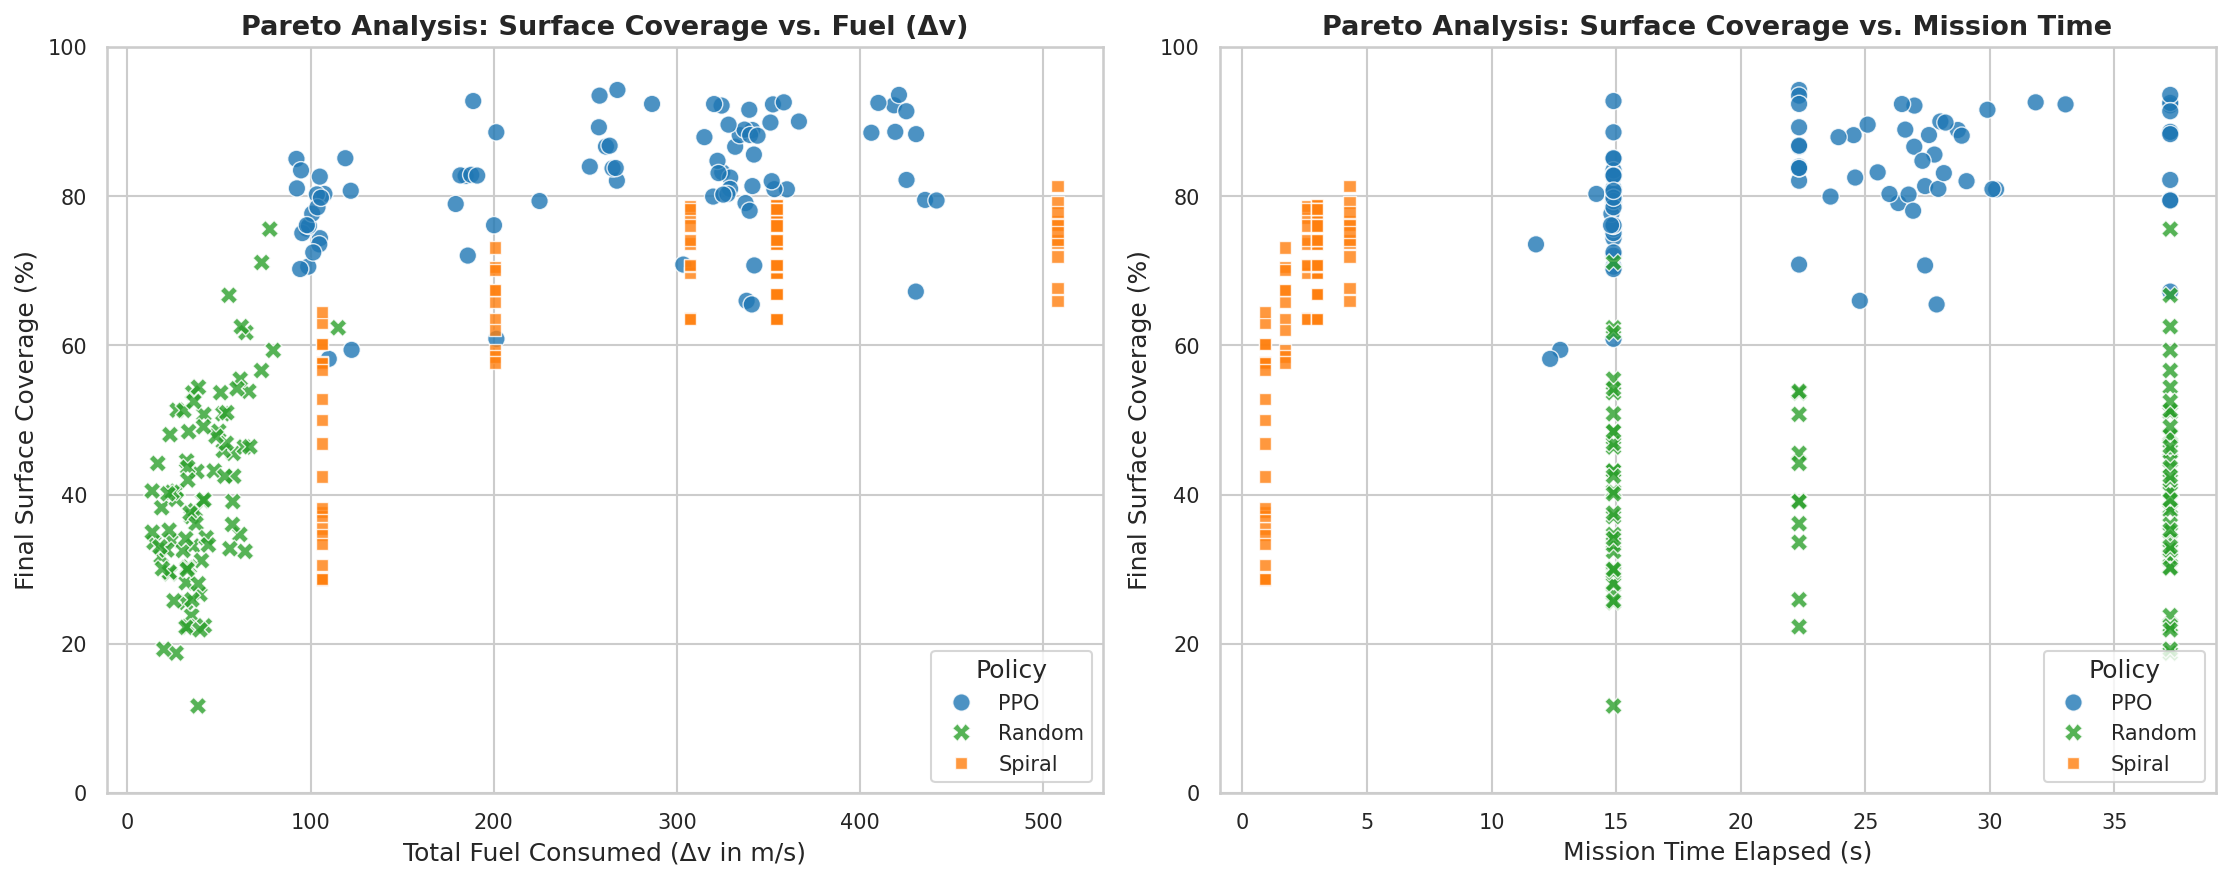

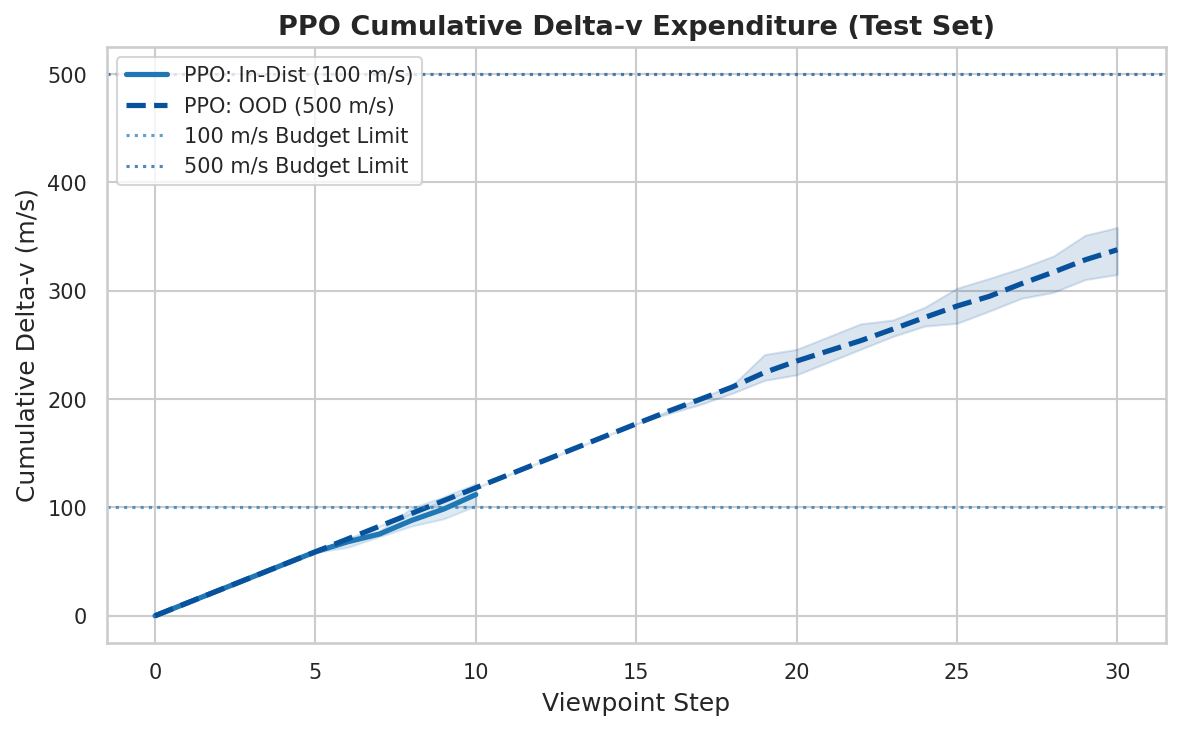

Exported docs/paper/figures/fig_ppo_fuel.pdf
=== Resource Efficiency Metric (Coverage % gained per 100 m/s Delta-v) ===


policy,PPO,Random,Spiral
config_label,,,
"Budget-200 (200 m/s, 2 orbits, 30 steps)",41.57,90.20,32.40
"Budget-300 (300 m/s, 3 orbits, 30 steps)",32.26,120.99,23.57
"InDist-10 (100 m/s, 2 orbits, 10 steps)",75.28,105.63,52.90
"InDist-30 (100 m/s, 2 orbits, 30 steps)",73.33,92.49,32.84
"KOZ-0.85 (500 m/s, 5 orbits, KOZ Tight)",24.98,94.65,20.51
"KOZ-1.05 (500 m/s, 5 orbits, KOZ Wide)",25.12,108.04,20.51
"OOD-500-30 (500 m/s, 5 orbits, 30 steps)",24.71,136.66,20.51
"OOD-500-50 (500 m/s, 5 orbits, 50 steps)",20.26,145.37,14.67


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Coverage vs Total Delta-v Consumed
ax1 = axes[0]
sns.scatterplot(
    data=test_final,
    x="cumulative_dv",
    y="coverage_pct",
    hue="policy",
    style="policy",
    palette=POLICY_COLORS,
    s=70,
    alpha=0.8,
    ax=ax1
)
ax1.set_title("Pareto Analysis: Surface Coverage vs. Fuel (Δv)", fontweight="bold")
ax1.set_xlabel("Total Fuel Consumed (Δv in m/s)")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="lower right")

# Panel 2: Coverage vs Mission Time Elapsed
ax2 = axes[1]
sns.scatterplot(
    data=test_final,
    x="mission_time",
    y="coverage_pct",
    hue="policy",
    style="policy",
    palette=POLICY_COLORS,
    s=70,
    alpha=0.8,
    ax=ax2
)
ax2.set_title("Pareto Analysis: Surface Coverage vs. Mission Time", fontweight="bold")
ax2.set_xlabel("Mission Time Elapsed (s)")
ax2.set_ylabel("Final Surface Coverage (%)")
ax2.set_ylim(0, 100)
ax2.legend(title="Policy", loc="lower right")

plt.tight_layout()
plt.show()

# Export Paper Figure: fig_ppo_fuel
fig_fuel, ax_fuel = plt.subplots(figsize=(8, 5))
sub_ppo = df[(df["policy"] == "PPO") & (df["dataset_split"] == "Test")]
fuel_scenarios = [
    ("InDist-30 (100 m/s, 2 orbits, 30 steps)", "In-Dist (100 m/s)", "#1f77b4", "-"),
    ("OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "OOD (500 m/s)", "#08519c", "--"),
]

for cfg_name, label, col, ls in fuel_scenarios:
    pol_sub = sub_ppo[sub_ppo["config_label"] == cfg_name]
    stats = pol_sub.groupby("step")["cumulative_dv"].agg(["mean", "min", "max"]).reset_index()
    ax_fuel.plot(stats["step"], stats["mean"], label=f"PPO: {label}", color=col, linestyle=ls, linewidth=2.5)
    ax_fuel.fill_between(stats["step"], stats["min"], stats["max"], color=col, alpha=0.15)

ax_fuel.axhline(100.0, color="#1f77b4", linestyle=":", alpha=0.7, label="100 m/s Budget Limit")
ax_fuel.axhline(500.0, color="#08519c", linestyle=":", alpha=0.7, label="500 m/s Budget Limit")
ax_fuel.set_title("PPO Cumulative Delta-v Expenditure (Test Set)", fontweight="bold")
ax_fuel.set_xlabel("Viewpoint Step")
ax_fuel.set_ylabel("Cumulative Delta-v (m/s)")
ax_fuel.legend(loc="upper left")
plt.tight_layout()
fig_fuel.savefig(os.path.join(FIG_DIR, "fig_ppo_fuel.pdf"), bbox_inches="tight")
fig_fuel.savefig(os.path.join(FIG_DIR, "fig_ppo_fuel.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Exported {FIG_DIR}/fig_ppo_fuel.pdf")

# Resource efficiency metric: Coverage % per 100 m/s Delta-v
test_final["fuel_efficiency"] = test_final["coverage_pct"] / np.maximum(test_final["cumulative_dv"], 1.0) * 100.0
eff_summary = test_final.groupby(["config_label", "policy"])["fuel_efficiency"].mean().round(2).unstack("policy")
print("=== Resource Efficiency Metric (Coverage % gained per 100 m/s Delta-v) ===")
display(eff_summary)

---

## 7. Distributional & Spacecraft-by-Spacecraft Heatmaps

We inspect policy performance across each individual spacecraft CAD model (e.g. Chandra, Clementine, MRO, Apollo-Soyuz, Terra, Stardust).

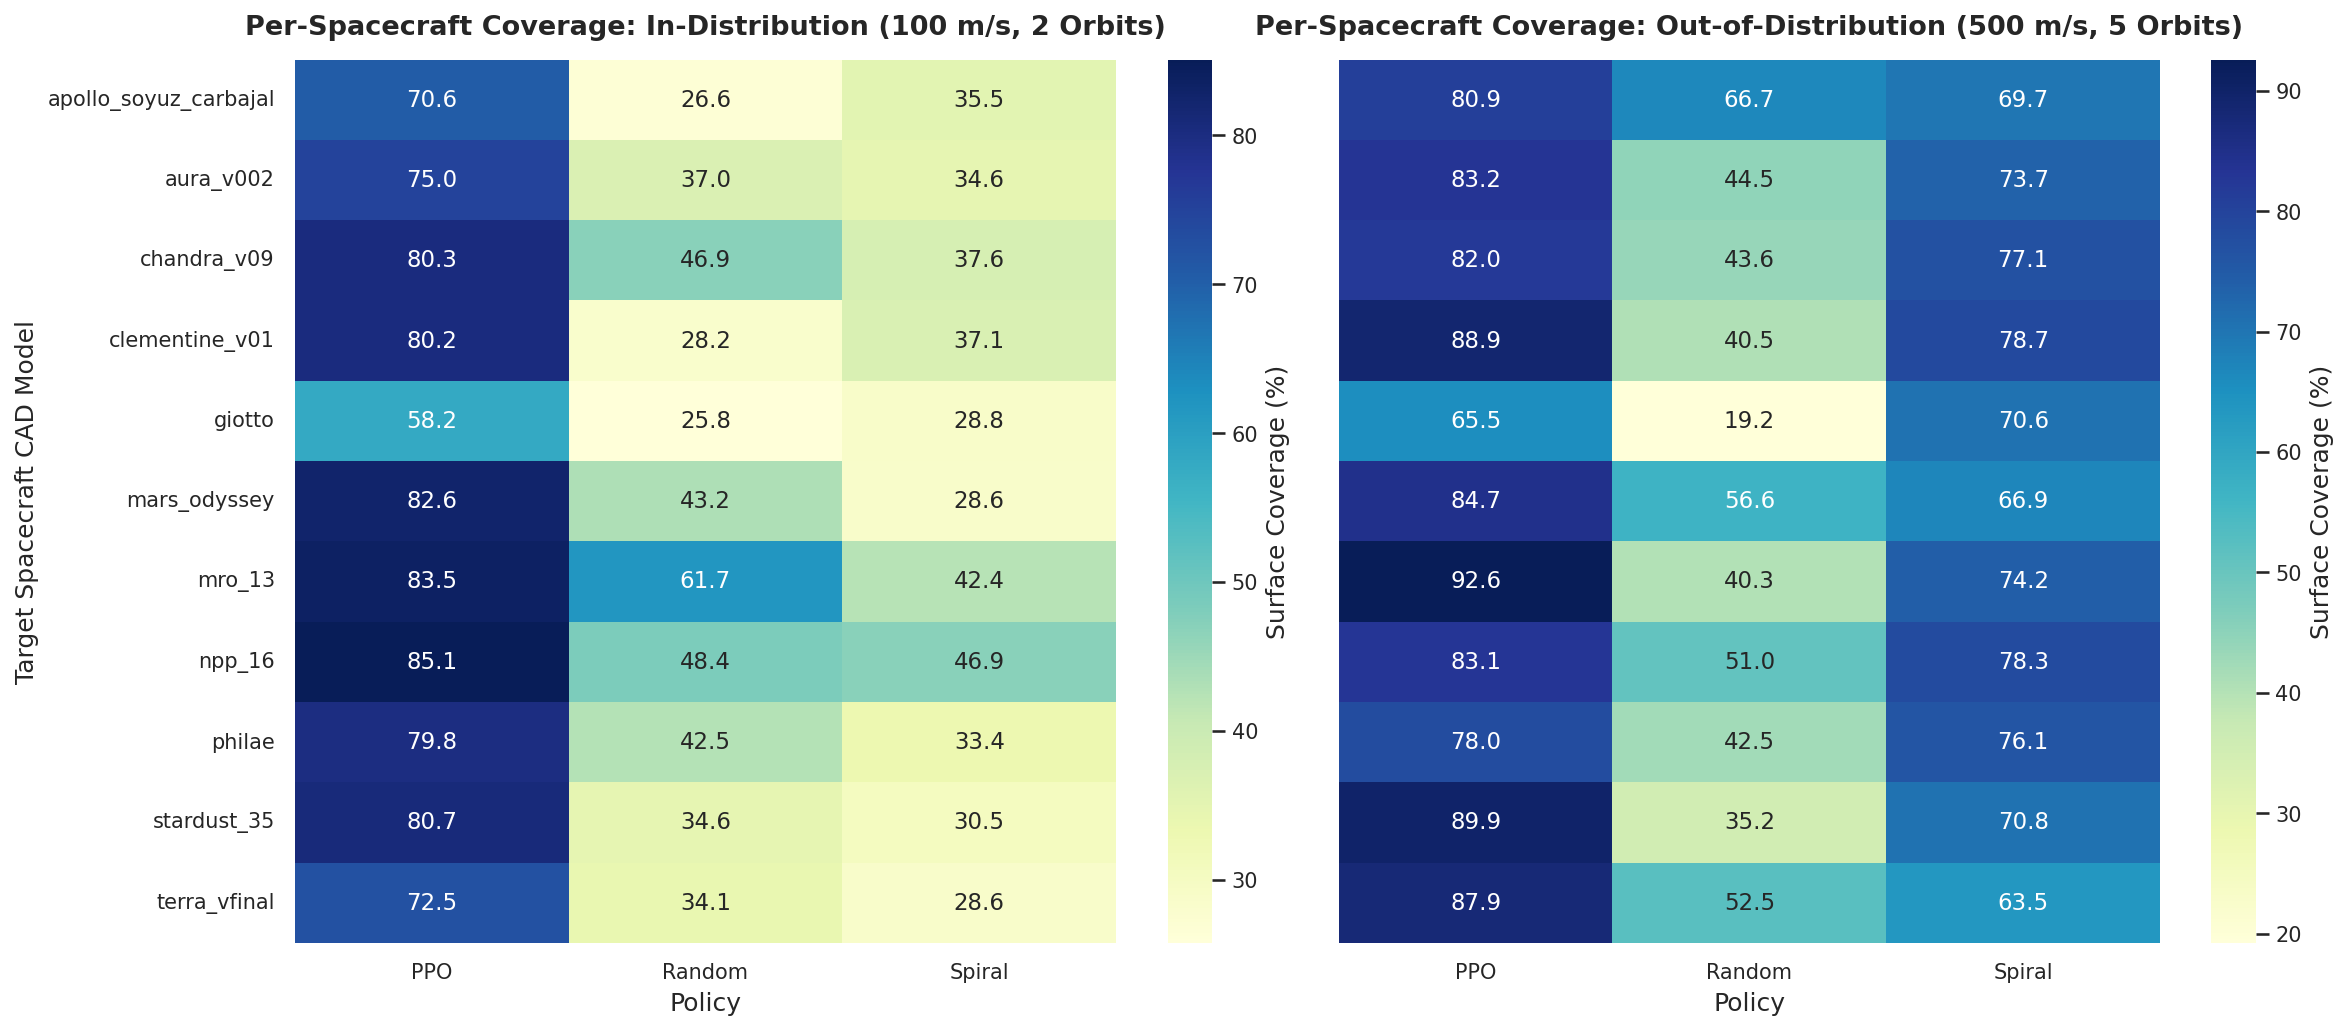

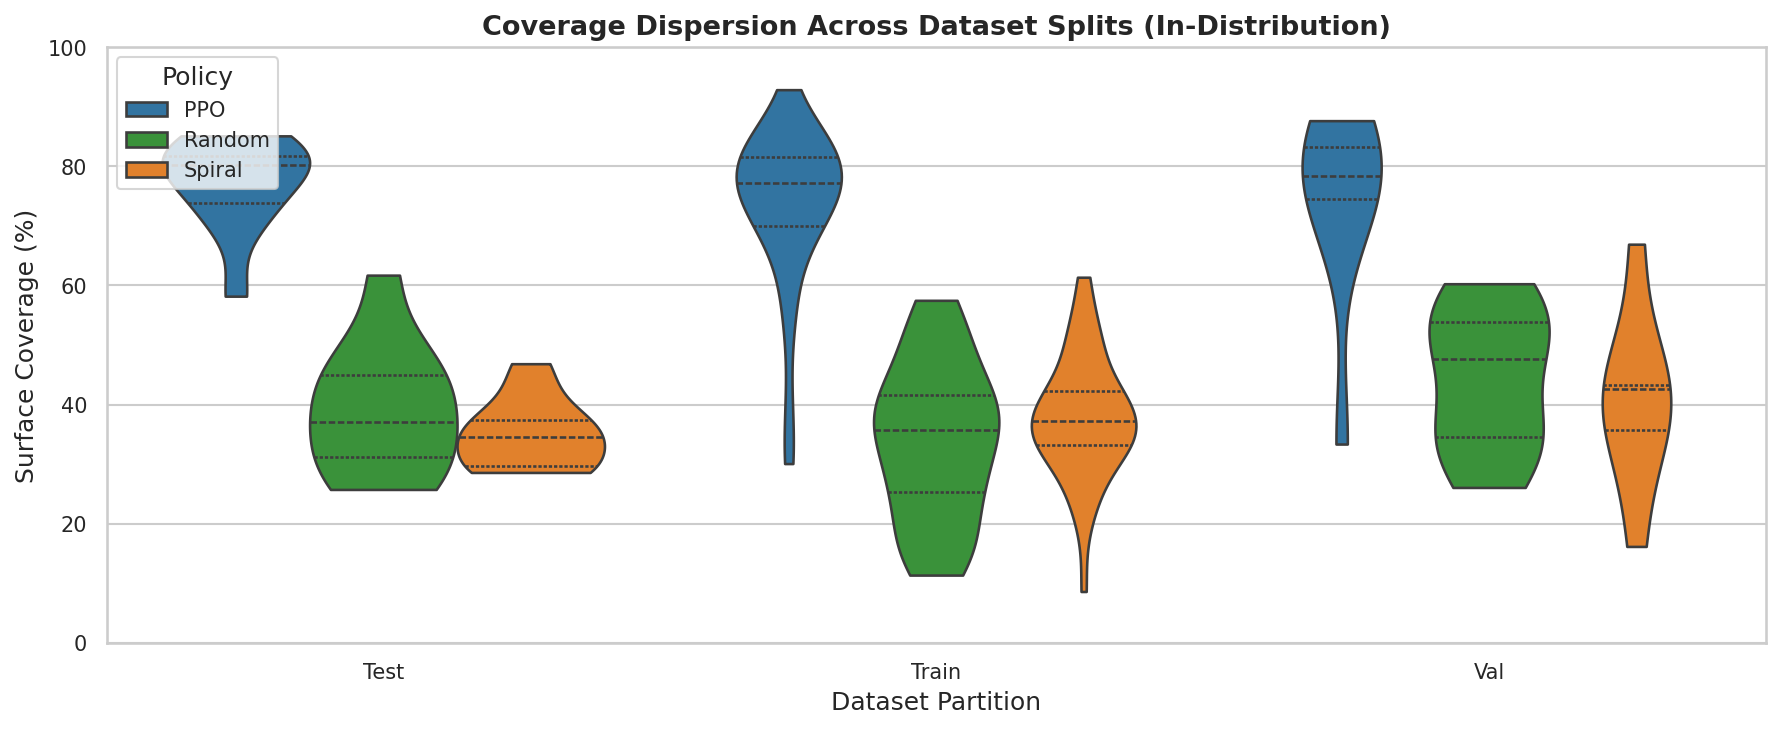

In [8]:
# 1. Model-by-Model Heatmaps (In-Distribution vs Out-of-Distribution Test Split)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for i, (cfg_name, cfg_title) in enumerate([
    ("InDist-30 (100 m/s, 2 orbits, 30 steps)", "In-Distribution (100 m/s, 2 Orbits)"),
    ("OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "Out-of-Distribution (500 m/s, 5 Orbits)")
]):
    sub_cfg = df_final[(df_final["config_label"] == cfg_name) & (df_final["dataset_split"] == "Test")]
    model_pivot = sub_cfg.pivot_table(index="model_name", columns="policy", values="coverage_pct").round(2)
    sns.heatmap(model_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Surface Coverage (%)'}, ax=axes[i])
    axes[i].set_title(f"Per-Spacecraft Coverage: {cfg_title}", fontweight="bold", pad=12)
    axes[i].set_ylabel("Target Spacecraft CAD Model" if i == 0 else "")
    axes[i].set_xlabel("Policy")

plt.tight_layout()
plt.show()

# 2. Violin Plot of Performance Distributions Across Splits
indist_final = df_final[df_final["config_label"] == "InDist-30 (100 m/s, 2 orbits, 30 steps)"]
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=indist_final,
    x="dataset_split",
    y="coverage_pct",
    hue="policy",
    palette=POLICY_COLORS,
    cut=0,
    inner="quartile"
)
plt.title("Coverage Dispersion Across Dataset Splits (In-Distribution)", fontweight="bold")
plt.xlabel("Dataset Partition")
plt.ylabel("Surface Coverage (%)")
plt.ylim(0, 100)
plt.legend(title="Policy", loc="upper left")
plt.tight_layout()
plt.show()

---

## 8. 3D Spatial Viewpoint Trajectory Visualizations

We plot the 3D inspection trajectory around the chief spacecraft on the spherical inspection shell.

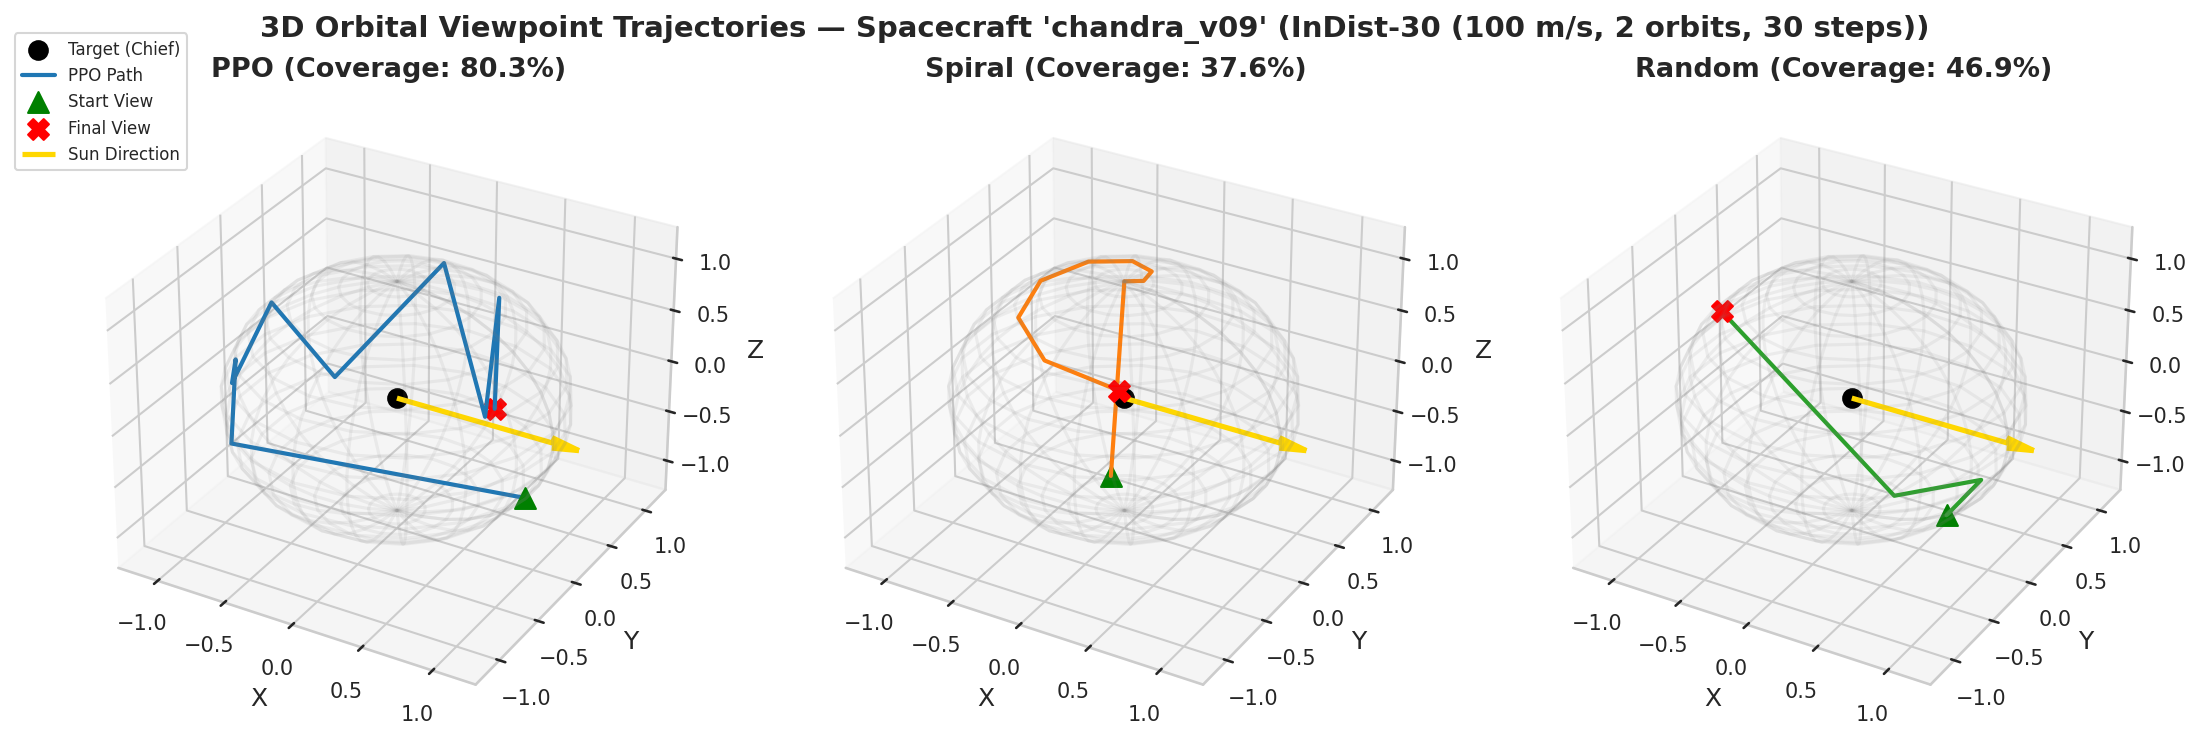

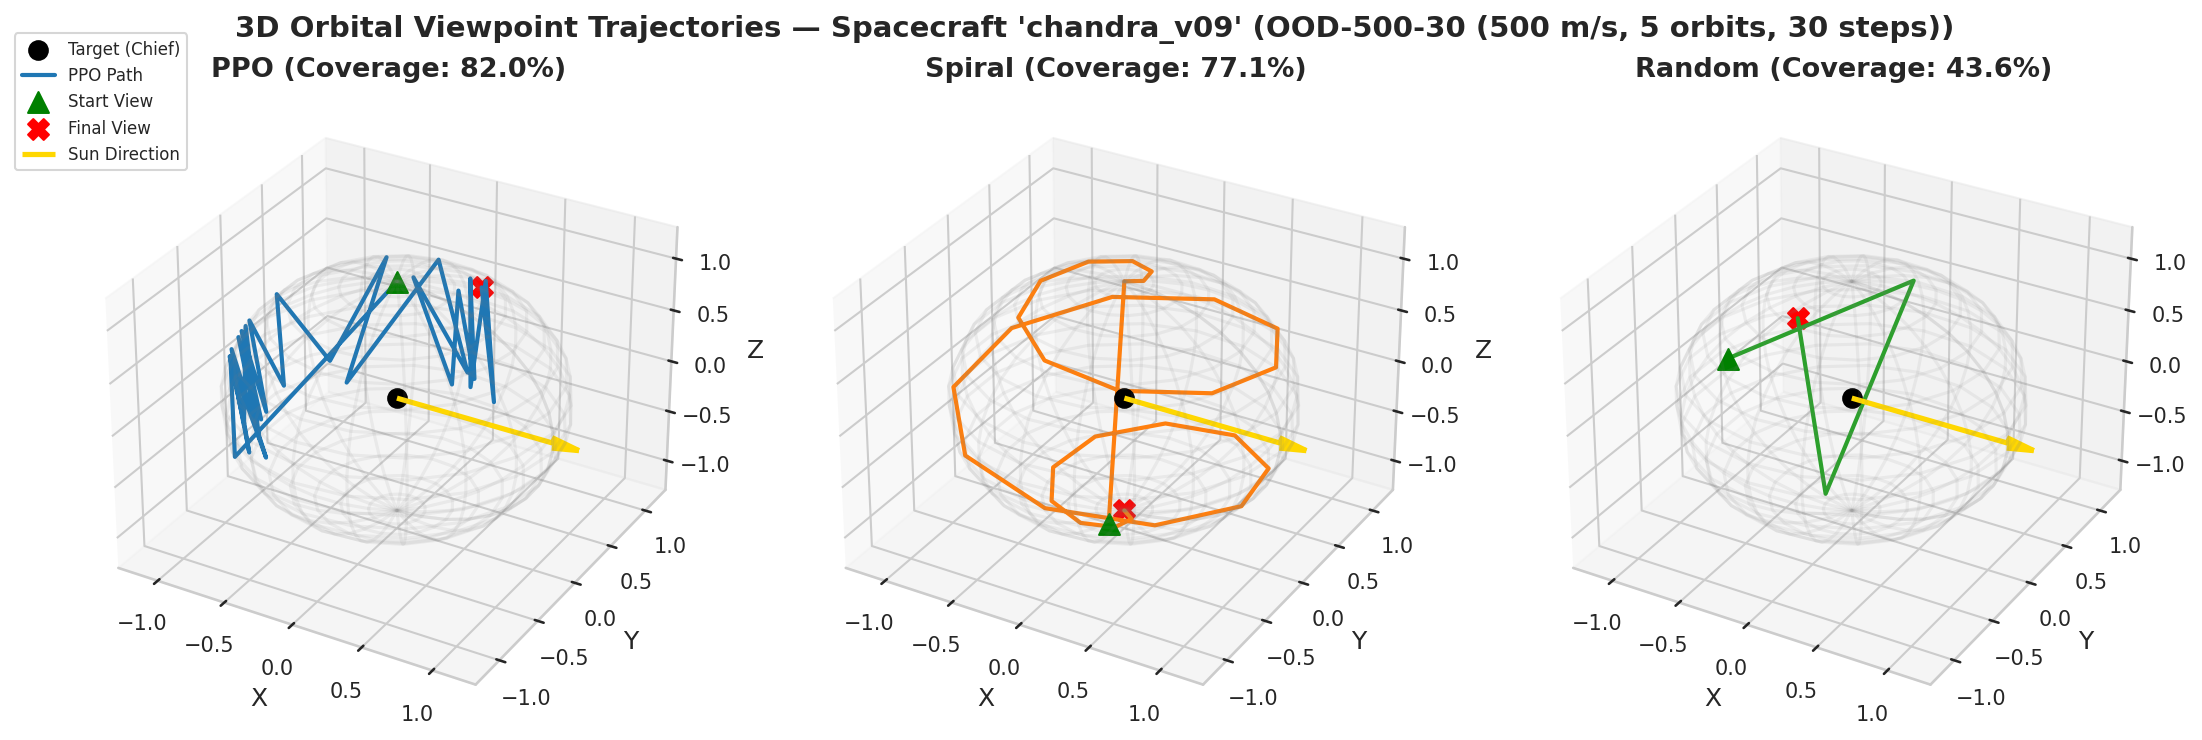

In [9]:
def plot_3d_inspection_trajectory(df_data, model_name, split="Test", config_name="InDist-30 (100 m/s, 2 orbits, 30 steps)"):
    sub = df_data[
        (df_data["model_name"] == model_name) & 
        (df_data["dataset_split"] == split) & 
        (df_data["config_label"] == config_name)
    ]
    if sub.empty:
        print(f"No trajectory records for model '{model_name}'.")
        return
        
    fig = plt.figure(figsize=(15, 5))
    policies = [p for p in ["PPO", "Spiral", "Random"] if p in sub["policy"].unique()]
    
    for i, pol in enumerate(policies, 1):
        ax = fig.add_subplot(1, len(policies), i, projection='3d')
        pol_traj = sub[sub["policy"] == pol].sort_values("step")
        
        xs, ys, zs = pol_traj["camera_x"].values, pol_traj["camera_y"].values, pol_traj["camera_z"].values
        
        # Plot wireframe orbit sphere (R=1.12)
        u = np.linspace(0, 2 * np.pi, 20)
        v = np.linspace(0, np.pi, 20)
        sx = 1.12 * np.outer(np.cos(u), np.sin(v))
        sy = 1.12 * np.outer(np.sin(u), np.sin(v))
        sz = 1.12 * np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_wireframe(sx, sy, sz, color="gray", alpha=0.1)
        
        # Plot target center
        ax.scatter([0], [0], [0], color="black", s=80, marker="o", label="Target (Chief)")
        
        # Plot trajectory path
        color = POLICY_COLORS.get(pol, "blue")
        ax.plot(xs, ys, zs, color=color, linewidth=2, label=f"{pol} Path")
        
        # Initial and Final Viewpoints
        if len(xs) > 0:
            ax.scatter([xs[0]], [ys[0]], [zs[0]], color="green", s=100, marker="^", label="Start View")
            ax.scatter([xs[-1]], [ys[-1]], [zs[-1]], color="red", s=100, marker="X", label="Final View")
            
        # Sun vector
        sun_x = pol_traj["sun_x"].iloc[0] if "sun_x" in pol_traj.columns else 1.0
        sun_y = pol_traj["sun_y"].iloc[0] if "sun_y" in pol_traj.columns else 0.0
        sun_z = pol_traj["sun_z"].iloc[0] if "sun_z" in pol_traj.columns else 0.0
        ax.quiver(0, 0, 0, sun_x*1.3, sun_y*1.3, sun_z*1.3, color="gold", linewidth=2.5, arrow_length_ratio=0.15, label="Sun Direction")
        
        cov_final = pol_traj["coverage_pct"].iloc[-1] if len(pol_traj) > 0 else 0.0
        ax.set_title(f"{pol} (Coverage: {cov_final:.1f}%)", fontweight="bold")
        ax.set_xlim([-1.3, 1.3])
        ax.set_ylim([-1.3, 1.3])
        ax.set_zlim([-1.3, 1.3])
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        if i == 1:
            ax.legend(loc="upper left", bbox_to_anchor=(-0.1, 1.1), fontsize=8)
            
    plt.suptitle(f"3D Orbital Viewpoint Trajectories — Spacecraft '{model_name}' ({config_name})", fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

# Plot representative spacecraft trajectories
plot_3d_inspection_trajectory(df, model_name="chandra_v09", config_name="InDist-30 (100 m/s, 2 orbits, 30 steps)")
plot_3d_inspection_trajectory(df, model_name="chandra_v09", config_name="OOD-500-30 (500 m/s, 5 orbits, 30 steps)")

---

## 9. Training Diagnostics & Learning Progression

We parse the evaluation checkpoint progression from `artefacts/train/train_result_500_5.txt` and any available SB3 training metrics to analyze policy convergence, entropy decay, and coverage curve evolution.

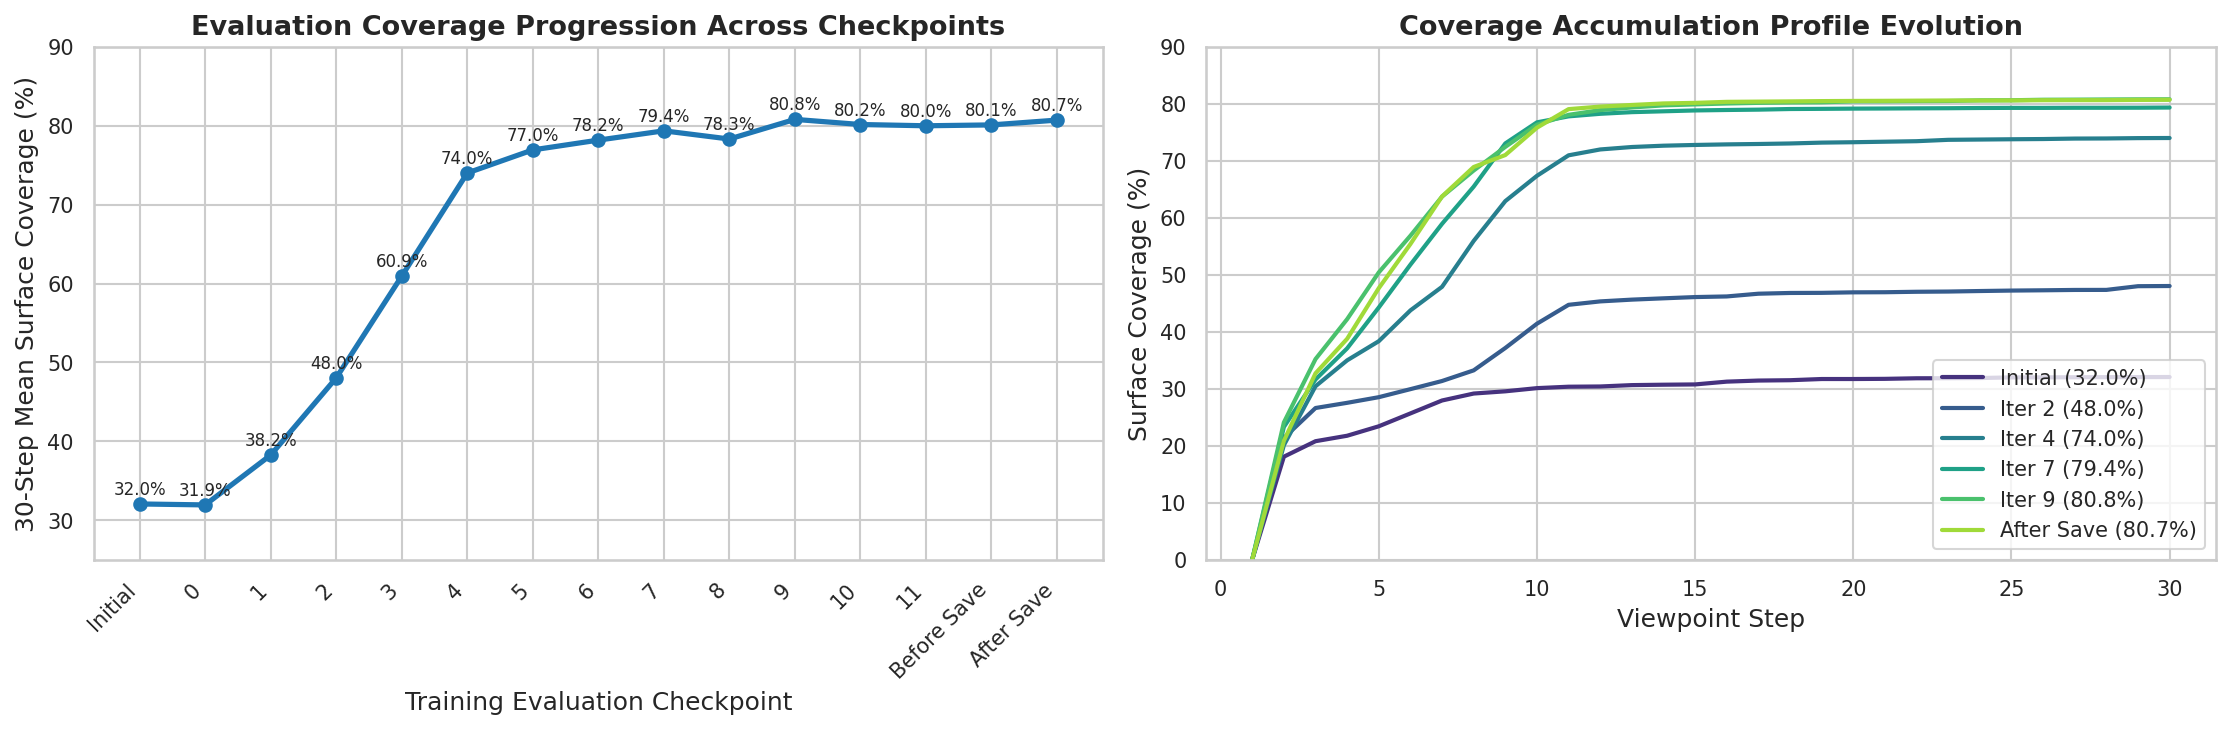

Exported docs/paper/figures/fig_training_progression.pdf


In [10]:
# 1. Parse evaluation progression across training checkpoints
train_result_path = "artefacts/train/train_result_500_5.txt"
records, current_iter = [], None

if os.path.exists(train_result_path):
    with open(train_result_path, "r", encoding="utf-8") as f:
        for line in f:
            line_s = line.strip()
            m_iter = re.match(r"------\s+(.*?)\s+------", line_s)
            if m_iter:
                current_iter = m_iter.group(1)
                continue
            if line_s.startswith("average_coverage:"):
                vals = re.findall(r"\[(\d+)\]:([0-9\.]+)", line_s)
                if vals:
                    tag = "Initial" if current_iter is None else current_iter
                    step_dict = {int(s): float(v) for s, v in vals}
                    records.append({
                        "iteration": tag,
                        "final_cov": step_dict[max(step_dict.keys())],
                        "step_covs": step_dict
                    })

df_train_prog = pd.DataFrame(records)

if not df_train_prog.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Panel 1: Learning Curve Across Checkpoints
    ax1 = axes[0]
    ax1.plot(range(len(df_train_prog)), df_train_prog["final_cov"], marker="o", color="#1f77b4", linewidth=2.5)
    ax1.set_xticks(range(len(df_train_prog)))
    ax1.set_xticklabels(df_train_prog["iteration"], rotation=45, ha="right")
    ax1.set_title("Evaluation Coverage Progression Across Checkpoints", fontweight="bold")
    ax1.set_xlabel("Training Evaluation Checkpoint")
    ax1.set_ylabel("30-Step Mean Surface Coverage (%)")
    ax1.set_ylim(25, 90)
    for idx, row in df_train_prog.iterrows():
        ax1.annotate(f"{row['final_cov']:.1f}%", (idx, row["final_cov"] + 1.2), ha="center", fontsize=8)
        
    # Panel 2: Step-by-Step Trajectory Profile Evolution
    ax2 = axes[1]
    highlight_iters = ["Initial", "2", "4", "7", "9", "After Save"]
    palette_iter = sns.color_palette("viridis", len(highlight_iters))
    for i, it_name in enumerate(highlight_iters):
        matching = df_train_prog[df_train_prog["iteration"] == it_name]
        if not matching.empty:
            steps_dict = matching.iloc[0]["step_covs"]
            steps = sorted(steps_dict.keys())
            covs = [steps_dict[s] for s in steps]
            label = f"Iter {it_name}" if it_name.isdigit() else it_name
            ax2.plot(steps, covs, label=f"{label} ({covs[-1]:.1f}%)", color=palette_iter[i], linewidth=2.0)
            
    ax2.set_title("Coverage Accumulation Profile Evolution", fontweight="bold")
    ax2.set_xlabel("Viewpoint Step")
    ax2.set_ylabel("Surface Coverage (%)")
    ax2.set_ylim(0, 90)
    ax2.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No checkpoint evaluation log found at '{train_result_path}'.")

# 2. SB3 Scalar Diagnostics (Entropy, KL, Value Loss) if progress.csv exists
sb3_log_csv = "artefacts/train/sb3_logs/progress.csv"
stdout_log = "container_stdout.log"

def load_sb3_training_progress(csv_p, text_p):
    if os.path.exists(csv_p):
        print(f"Loaded SB3 training metrics from CSV: '{csv_p}'")
        return pd.read_csv(csv_p)
    if os.path.exists(text_p):
        print(f"Parsing SB3 metrics from '{text_p}'...")
        sb3_recs, rec = [], {}
        with open(text_p, "r", encoding="utf-8") as f:
            for line in f:
                match = re.search(r"\|\s+([\w\/]+)\s+\|\s+([-\d\.e+]+)\s+\|", line)
                if match:
                    k, v = match.group(1).strip(), float(match.group(2))
                    rec[k] = v
                if line.strip().startswith("---------------------------------") and rec:
                    if any(k in rec for k in ["time/total_timesteps", "train/approx_kl", "train/entropy_loss", "train/value_loss"]):
                        sb3_recs.append(rec.copy())
                        rec = {}
        return pd.DataFrame(sb3_recs)
    return pd.DataFrame()

df_sb3 = load_sb3_training_progress(sb3_log_csv, stdout_log)
if not df_sb3.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    x_axis = "time/total_timesteps" if "time/total_timesteps" in df_sb3.columns else df_sb3.index
    if "train/entropy_loss" in df_sb3.columns:
        axes[0].plot(df_sb3[x_axis], -df_sb3["train/entropy_loss"], color="purple", linewidth=2.0)
        axes[0].set_title("Policy Entropy (-entropy_loss)", fontweight="bold")
        axes[0].set_xlabel("Total Timesteps")
        axes[0].set_ylabel("Entropy")
    if "train/approx_kl" in df_sb3.columns:
        axes[1].plot(df_sb3[x_axis], df_sb3["train/approx_kl"], color="teal", linewidth=2.0)
        axes[1].set_title("Approximate KL Divergence", fontweight="bold")
        axes[1].set_xlabel("Total Timesteps")
        axes[1].set_ylabel("Approx KL")
    if "train/value_loss" in df_sb3.columns:
        axes[2].plot(df_sb3[x_axis], df_sb3["train/value_loss"], color="crimson", linewidth=2.0)
        axes[2].set_title("Value Function Loss", fontweight="bold")
        axes[2].set_xlabel("Total Timesteps")
        axes[2].set_ylabel("Value Loss")
    plt.suptitle("PPO SB3 Training Convergence Profile", fontsize=14, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()